Stuart Rossiter, C00284845

# Licensing
Convolutional Neural Network using the Cards Image Dataset-Classification Copyright (C) 2025 Stuart Rossiter 
https://www.kaggle.com/datasets/gpiosenka/cards-image-datasetclassification

This program is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation, either version 3 of the License, or (at your option) any later version.

This program is distributed in the hope that it will be useful, but WITHOUT ANY WARRANTY; without even the implied warranty of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU General Public License for more details.

You should have received a copy of the GNU General Public License along with this program. If not, see https://www.gnu.org/licenses/.

# Convolutional Neural Networks - Playing Card Detection
Using a Convolutional Neural Network, I will be training a model to recognise playing cards, and differentiate between the different suits and ranks.

# Preprocessing


In [3]:
import pandas as pd

all = pd.read_csv("cards.csv")

train_df = all[all["data set"] == "train"]
test_df  = all[all["data set"] == "test"]
valid_df = all[all["data set"] == "valid"]

X_train = train_df["filepaths"]
y_train = train_df["labels"]

X_test = test_df["filepaths"]
y_test = test_df["labels"]

X_valid = valid_df["filepaths"]
y_valid = valid_df["labels"]

resolution = (224, 224)
batch_size = 32

from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_dataframe(
    train_df,
    x_col="filepaths",
    y_col="labels",
    target_size=resolution,
    batch_size=batch_size,
    class_mode="categorical"
)

val_gen = datagen.flow_from_dataframe(
    valid_df,
    x_col="filepaths",
    y_col="labels",
    target_size=resolution,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

test_gen = datagen.flow_from_dataframe(
    test_df,
    x_col="filepaths",
    y_col="labels",
    target_size=resolution,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

from keras import Sequential
from keras.layers import Conv2D, Flatten, Dense, MaxPooling2D

model = Sequential()

model.add(Conv2D(32, (3,3), activation="relu", input_shape=(224, 224, 3)))
model.add(MaxPooling2D())

model.add(Conv2D(128, (3,3), activation="relu"))
model.add(MaxPooling2D())

model.add(Conv2D(128, (3,3), activation="relu"))
model.add(MaxPooling2D())

model.add(Conv2D(128, (3,3), activation="relu"))
model.add(MaxPooling2D())

model.add(Flatten())
model.add(Dense(128, "relu"))
model.add(Dense(len(train_gen.class_indices), "softmax"))
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

train_mod = model.fit(train_gen, validation_data=val_gen, epochs=10)

Found 7624 validated image filenames belonging to 53 classes.
Found 265 validated image filenames belonging to 53 classes.
Found 265 validated image filenames belonging to 53 classes.


C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\legacy\preprocessing\image.py:918: UserWarning: Found 1 invalid image filename(s) in x_col="filepaths". These filename(s) will be ignored.
  warnings.warn(
C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 171s 707ms/step - accuracy: 0.2959 - loss: 2.7058 - val_accuracy: 0.5321 - val_loss: 1.5635
Epoch 2/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 159s 664ms/step - accuracy: 0.6139 - loss: 1.4499 - val_accuracy: 0.7245 - val_loss: 0.9946
Epoch 3/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 158s 660ms/step - accuracy: 0.7531 - loss: 0.8773 - val_accuracy: 0.7774 - val_loss: 0.9452
Epoch 4/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 156s 651ms/step - accuracy: 0.8690 - loss: 0.4654 - val_accuracy: 0.8189 - val_loss: 0.8915
Epoch 5/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 156s 651ms/step - accuracy: 0.9304 - loss: 0.2654 - val_accuracy: 0.7736 - val_loss: 1.2264
Epoch 6/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 155s 650ms/step - accuracy: 0.9508 - loss: 0.1913 - val_accuracy: 0.8000 - val_loss: 1.2272
Epoch 7/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 156s 652ms/step - accuracy: 0.9722 - loss: 0.1241 - val_accuracy: 0.8038 - val_loss: 1.1457
Epoch 8/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 155s 650ms/step - accuracy: 0.9844 -

[]

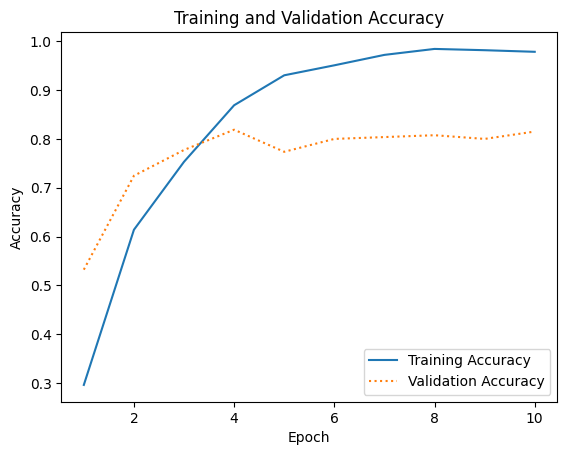

In [4]:
acc = train_mod.history['accuracy']
val_acc = train_mod.history['val_accuracy']
epochs = range(1, len(acc) + 1)

import matplotlib.pyplot as plt

plt.plot(epochs, acc, '-', label='Training Accuracy')
plt.plot(epochs, val_acc, ':', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.plot()

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 253ms/step


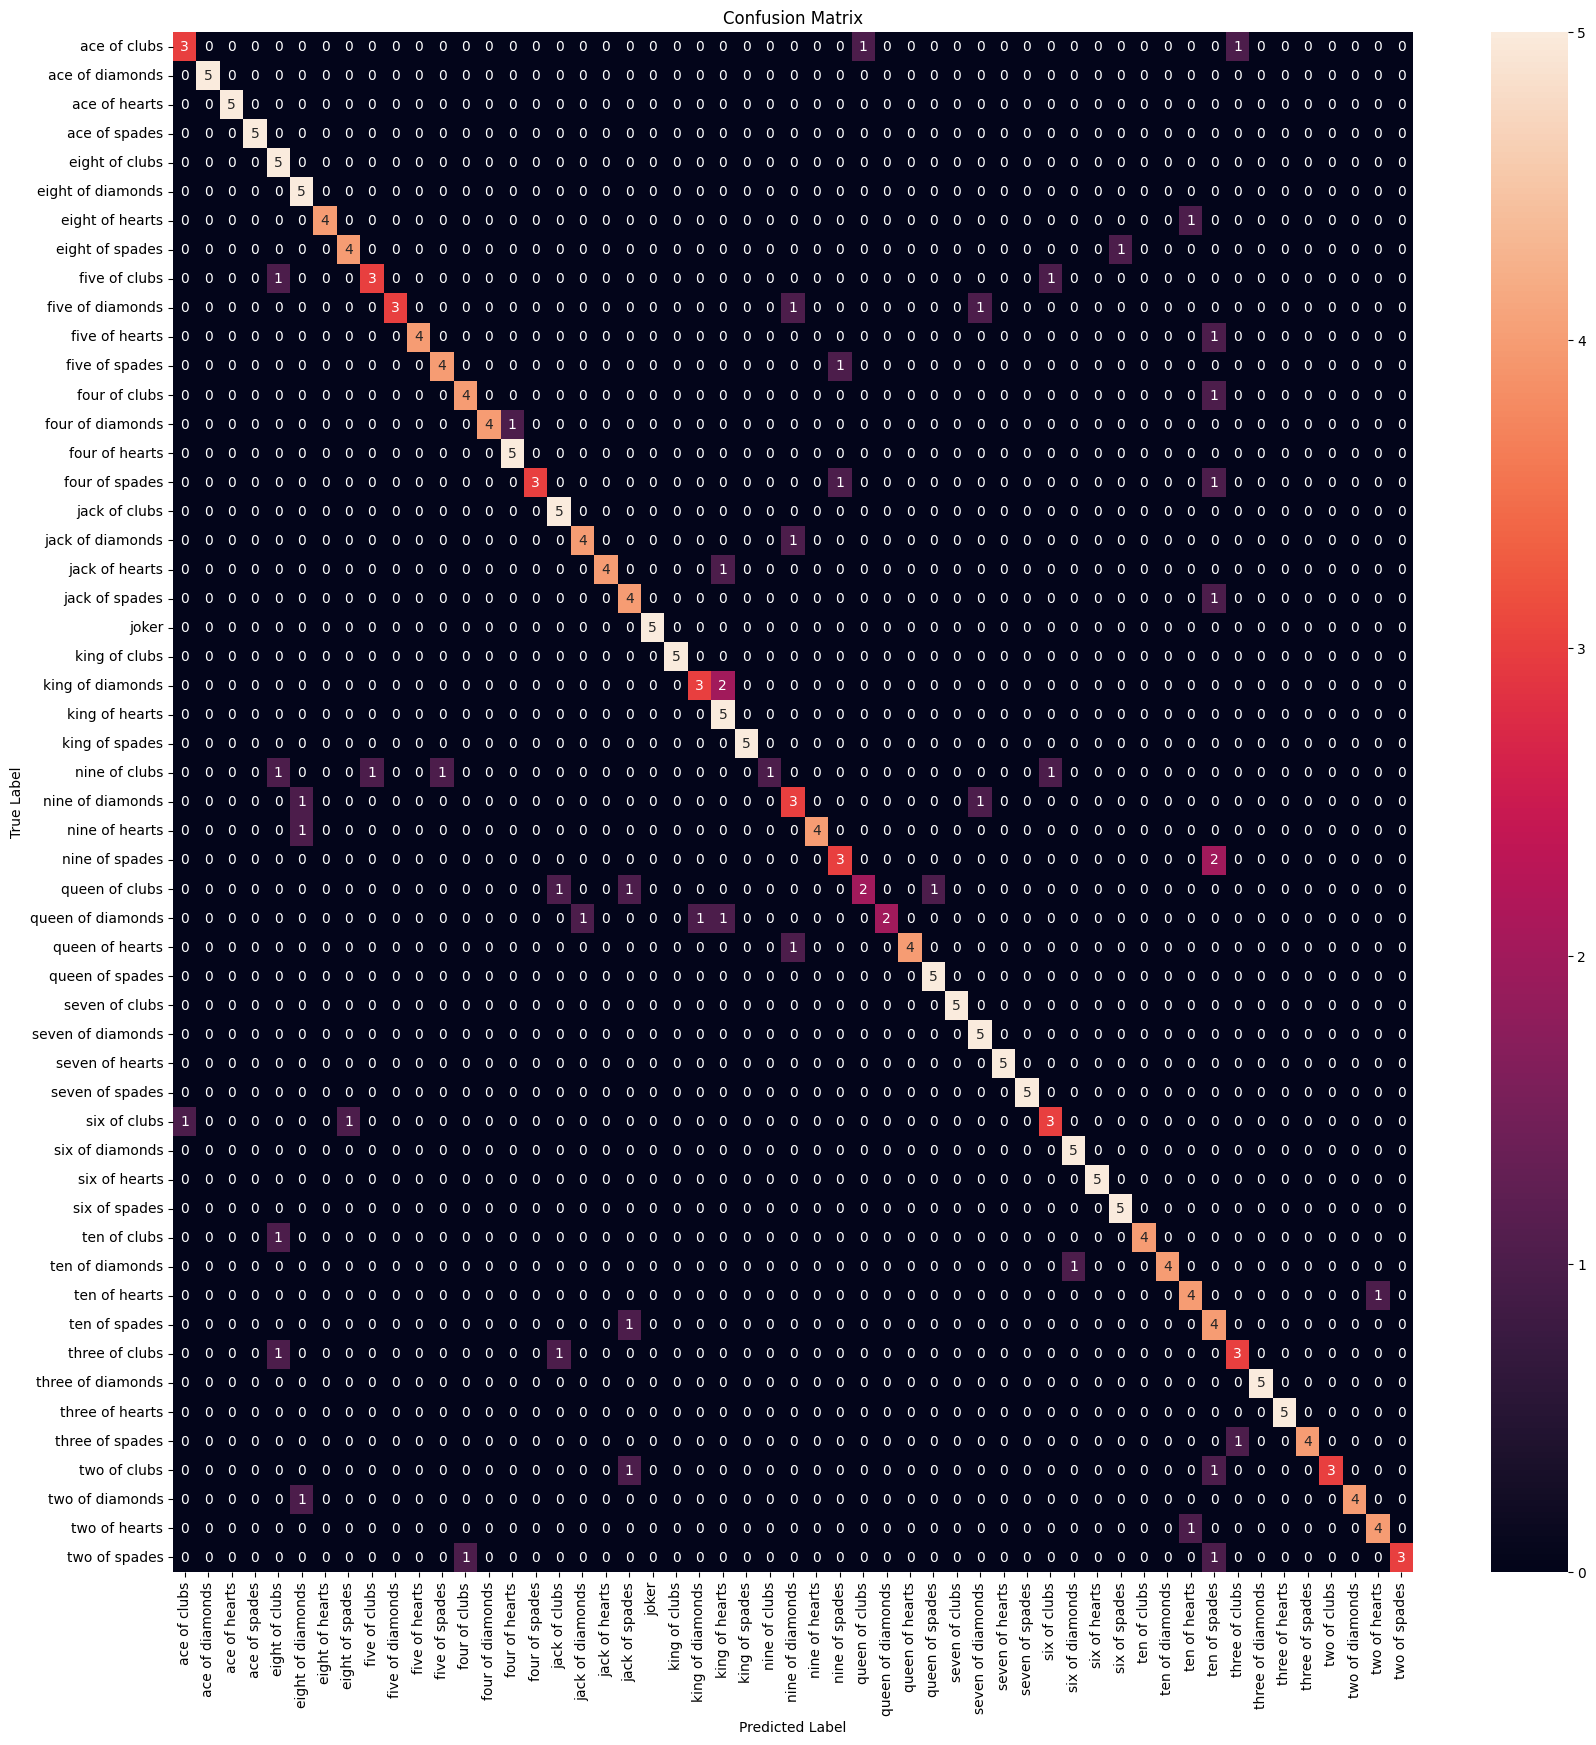

In [5]:
from sklearn.metrics import confusion_matrix
import seaborn as sb
import numpy as np

predictions = model.predict(test_gen)
true_labels = test_gen.classes
predicted_labels = np.argmax(predictions, axis=1)

cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(20, 20))
sb.heatmap(cm, annot=True, fmt="d",
            xticklabels=train_gen.class_indices.keys(),
            yticklabels=train_gen.class_indices.keys())
plt.ylabel("True Card")
plt.xlabel("Predicted Card")
plt.title("Confusion Matrix")
plt.show()